C:\Users\xiezhengyang\AppData\Local\Temp\ipykernel_13028\2041873860.py:25: RuntimeWarning: Mean of empty slice
  climatology_np[month - 1] = np.nanmean(xch4_values[month_indices, :, :], axis=0)


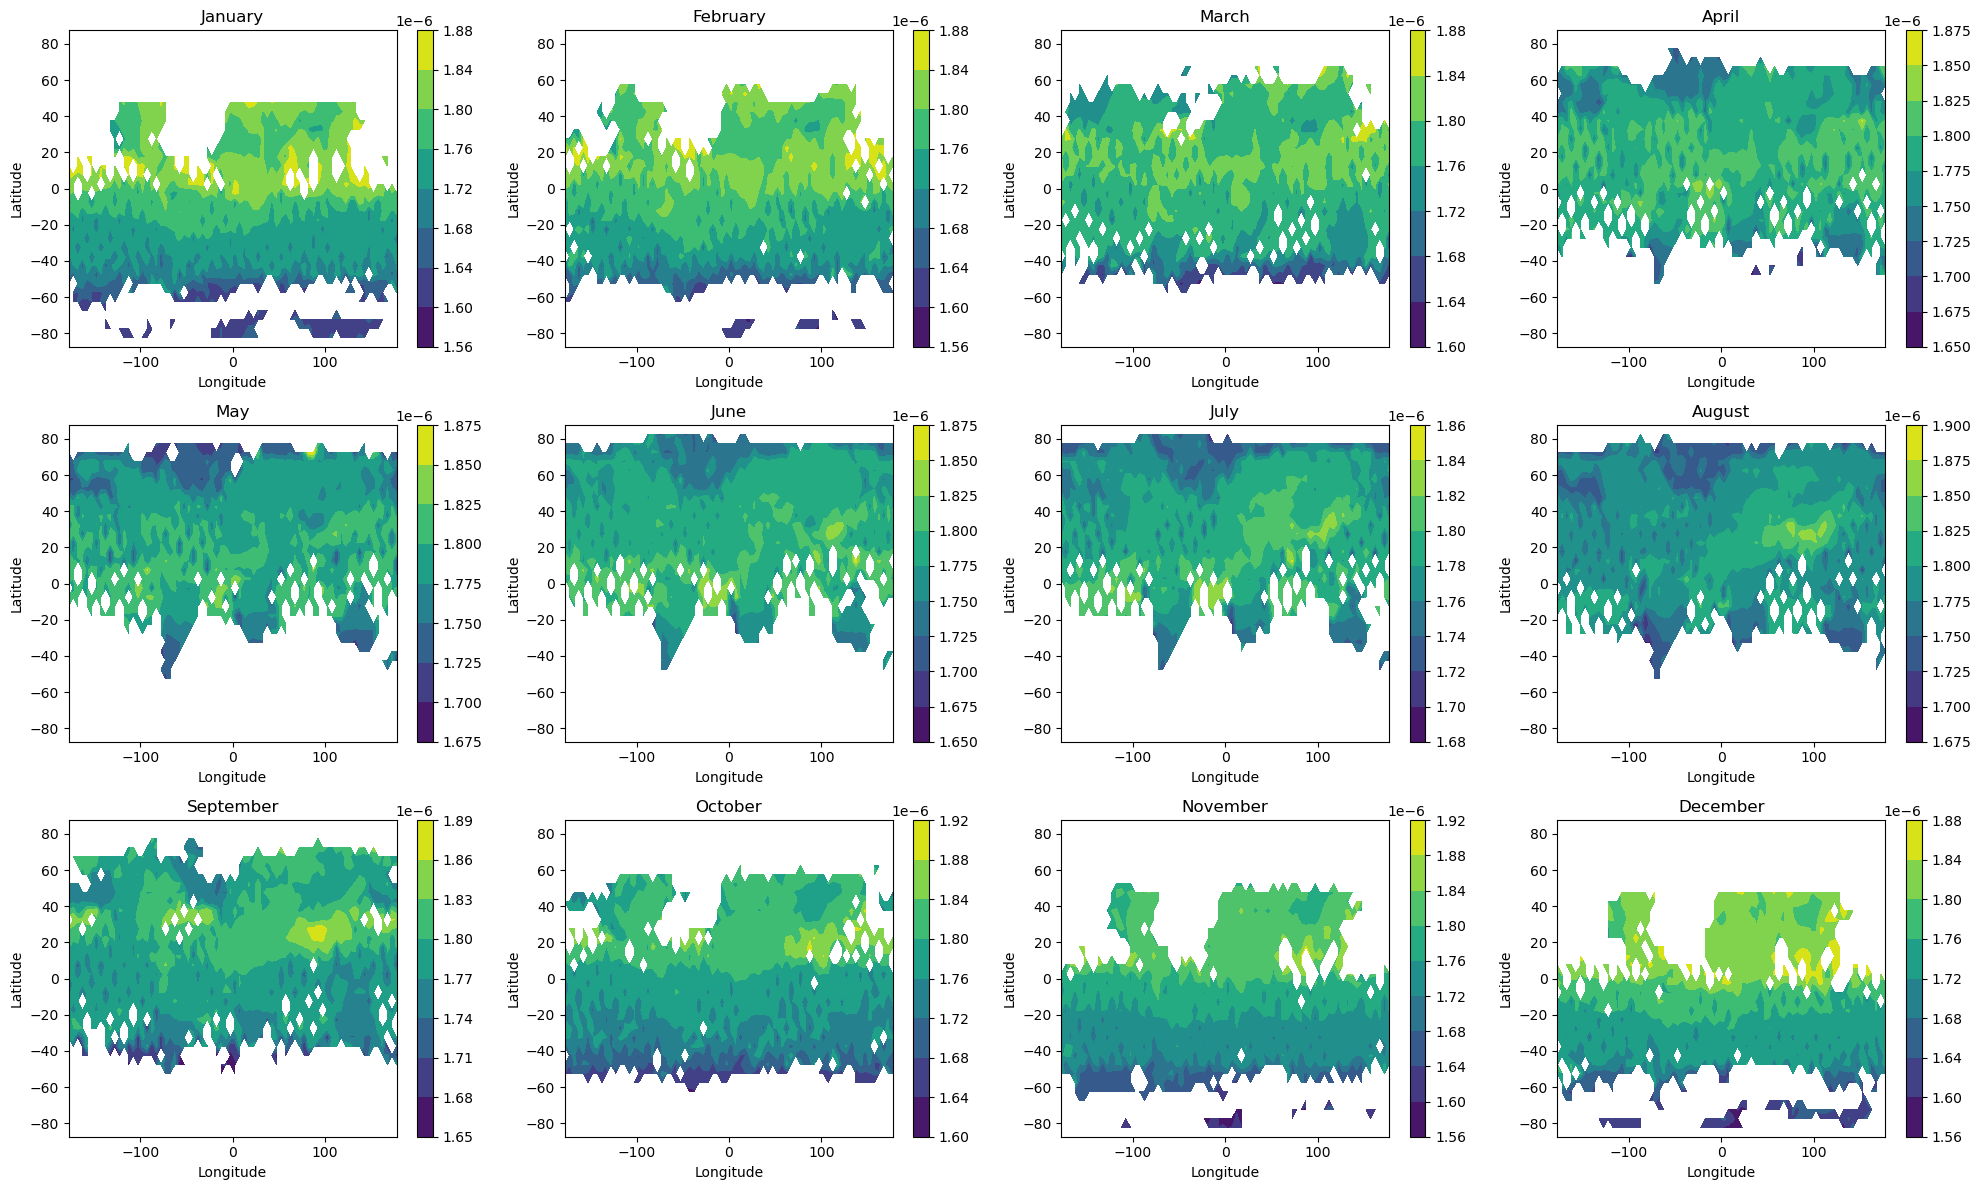

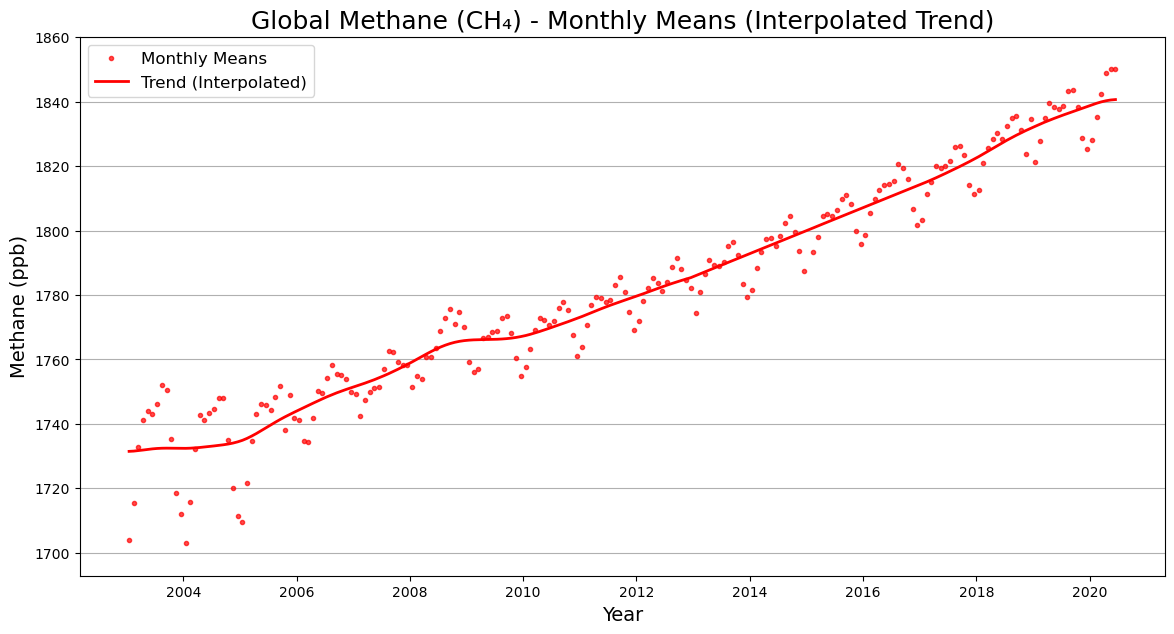

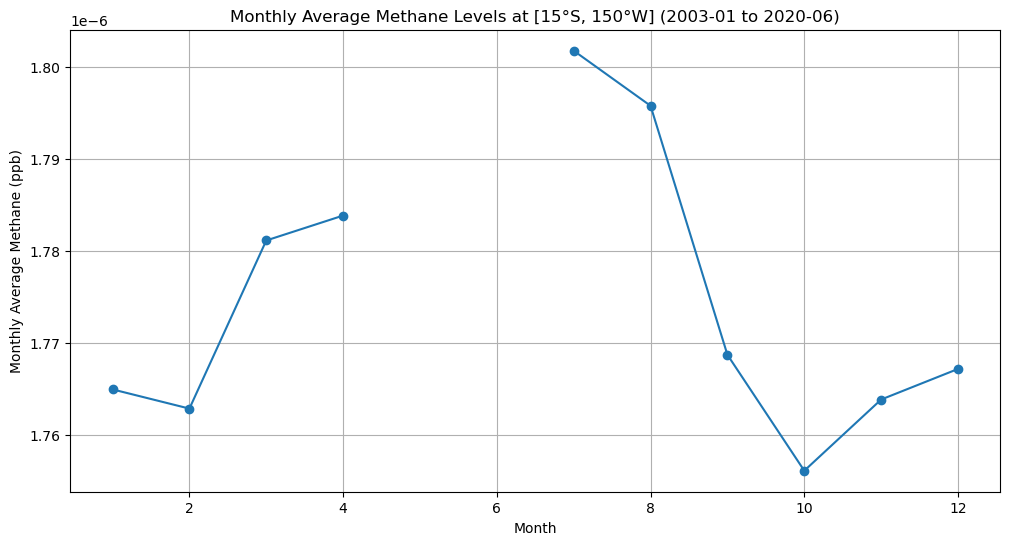

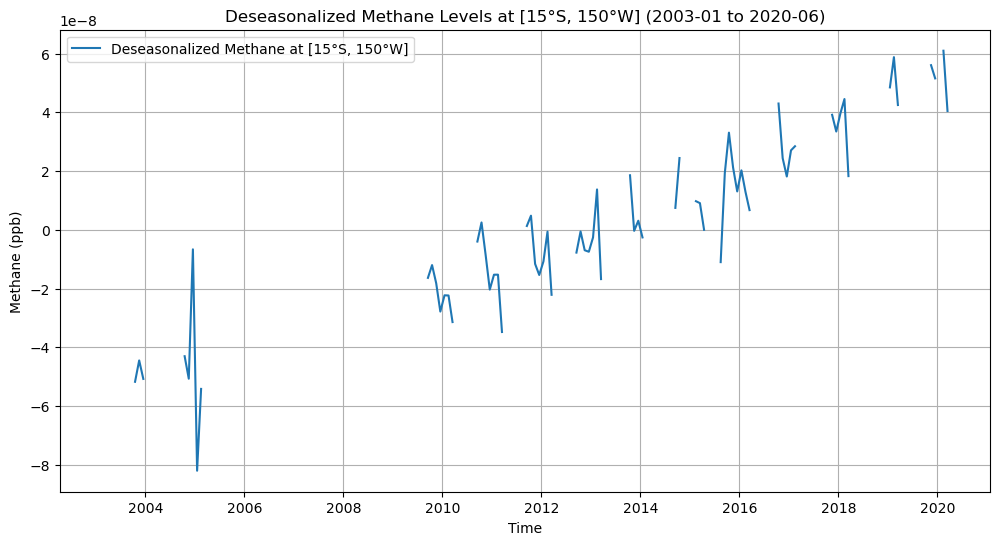

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# 加载 NetCDF 数据
data = xr.open_dataset("C:/Users/xiezhengyang/Desktop/200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc", engine="netcdf4")
# 显示数据变量以了解其结构
data
# 提取甲烷 (xch4) 和时间信息
xch4 = data['xch4']
time = data['time']
# 任何大于 1.0 的数字肯定都是无效填充值 (Fill Value)。
xch4 = xch4.where(xch4 < 1.0)

# 通过对所有年份的月份进行分组来计算月度气候态
monthly_climatology = xch4.groupby("time.month").mean(dim="time")
# 将数据集转换为 NumPy 数组以便进行分组操作
xch4_values = xch4.values
time_months = data['time.month'].values
# 使用 NumPy 计算气候态
climatology_np = np.zeros((12, xch4.shape[1], xch4.shape[2]))

for month in range(1, 13):
    month_indices = np.where(time_months == month)[0]
    climatology_np[month - 1] = np.nanmean(xch4_values[month_indices, :, :], axis=0)

# 在 12 个子图中绘制气候态
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

for i, ax in enumerate(axes.flat):
    c = ax.contourf(data['lon'], data['lat'], climatology_np[i], cmap='viridis')
    fig.colorbar(c, ax=ax)
    ax.set_title(months[i])
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

from scipy.ndimage import gaussian_filter1d

# 通过对每个时间点的经纬度维度求平均，计算全球平均甲烷水平
global_avg_methane = xch4.mean(dim=["lat", "lon"])

# 将甲烷水平从摩尔分数转换为 ppb
global_mean_methane_ppb_corrected = global_avg_methane * 1e9  # 转换为 ppb
smoothed_methane_ppb_corrected = gaussian_filter1d(global_mean_methane_ppb_corrected, sigma=6)

# 转换为 numpy 数组并确保数值有效（非 NaN/Infinite）
smoothed_trend_array = np.array(smoothed_methane_ppb_corrected)
valid_indices = np.isfinite(smoothed_trend_array)
interpolated_trend = np.interp(np.arange(len(smoothed_trend_array)), np.flatnonzero(valid_indices), smoothed_trend_array[valid_indices])

# 使用插值后的趋势值重新绘图
plt.figure(figsize=(14, 7))
plt.plot(data["time"], global_mean_methane_ppb_corrected, 'r.', label="Monthly Means", alpha=0.7)
plt.plot(data["time"], interpolated_trend, 'r-', label="Trend (Interpolated)", linewidth=2)
#plt.fill_between(data["time"],interpolated_trend.min()-10, interpolated_trend, color='pink',alpha=0.3)

plt.title("Global Methane (CH₄) - Monthly Means (Interpolated Trend)", fontsize=18)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Methane (ppb)", fontsize=14)
plt.grid(axis='y')
plt.legend(fontsize=12, loc="upper left")
plt.ylim(global_mean_methane_ppb_corrected.min() - 10, global_mean_methane_ppb_corrected.max() + 10)
plt.show()

# 提取特定位置 [15°S, 150°W] 的甲烷水平
location_methane = xch4.sel(lat=-15, lon=-150, method="nearest")

# 通过减去每个月的月度平均值（气候态）来去除季节性影响
location_monthly_climatology = location_methane.groupby("time.month").mean(dim="time")
deseasonalized_methane = location_methane.groupby("time.month") - location_monthly_climatology

# 绘制月度平均甲烷水平
plt.figure(figsize=(12, 6))
location_monthly_climatology.plot(marker='o')
plt.xlabel("Month")
plt.ylabel("Monthly Average Methane (ppb)")
plt.title("Monthly Average Methane Levels at [15°S, 150°W] (2003-01 to 2020-06)")
plt.grid(True)
plt.show()

# 绘制去除季节性影响后的甲烷水平
plt.figure(figsize=(12, 6))
plt.plot(time, deseasonalized_methane, label="Deseasonalized Methane at [15°S, 150°W]")
plt.xlabel("Time")
plt.ylabel("Methane (ppb)")
plt.title("Deseasonalized Methane Levels at [15°S, 150°W] (2003-01 to 2020-06)")
plt.legend()
plt.grid(True)
plt.show()

=== Nino 3.4 区域 SST 数据（前5个时间点） ===
<xarray.Dataset> Size: 3kB
Dimensions:  (lat: 5, lon: 26, time: 5)
Coordinates:
  * lat      (lat) float32 20B -4.0 -2.0 0.0 2.0 4.0
  * lon      (lon) float32 104B 190.0 192.0 194.0 196.0 ... 236.0 238.0 240.0
  * time     (time) datetime64[ns] 40B 1960-01-15 1960-02-15 ... 1960-05-15
Data variables:
    sst      (time, lat, lon) float32 3kB ...
Attributes:
    Conventions:  IRIDL
    source:       https://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCDC/.ERSST/...
    history:      extracted and cleaned by Ryan Abernathey for Research Compu...

=== Climatology（前5个月） ===
<xarray.Dataset> Size: 3kB
Dimensions:  (month: 5, lat: 5, lon: 26)
Coordinates:
  * lat      (lat) float32 20B -4.0 -2.0 0.0 2.0 4.0
  * lon      (lon) float32 104B 190.0 192.0 194.0 196.0 ... 236.0 238.0 240.0
  * month    (month) int64 40B 1 2 3 4 5
Data variables:
    sst      (month, lat, lon) float32 3kB 28.6 28.47 28.33 ... 28.02 28.06
Attributes:
    Conventions:  IRIDL
    source

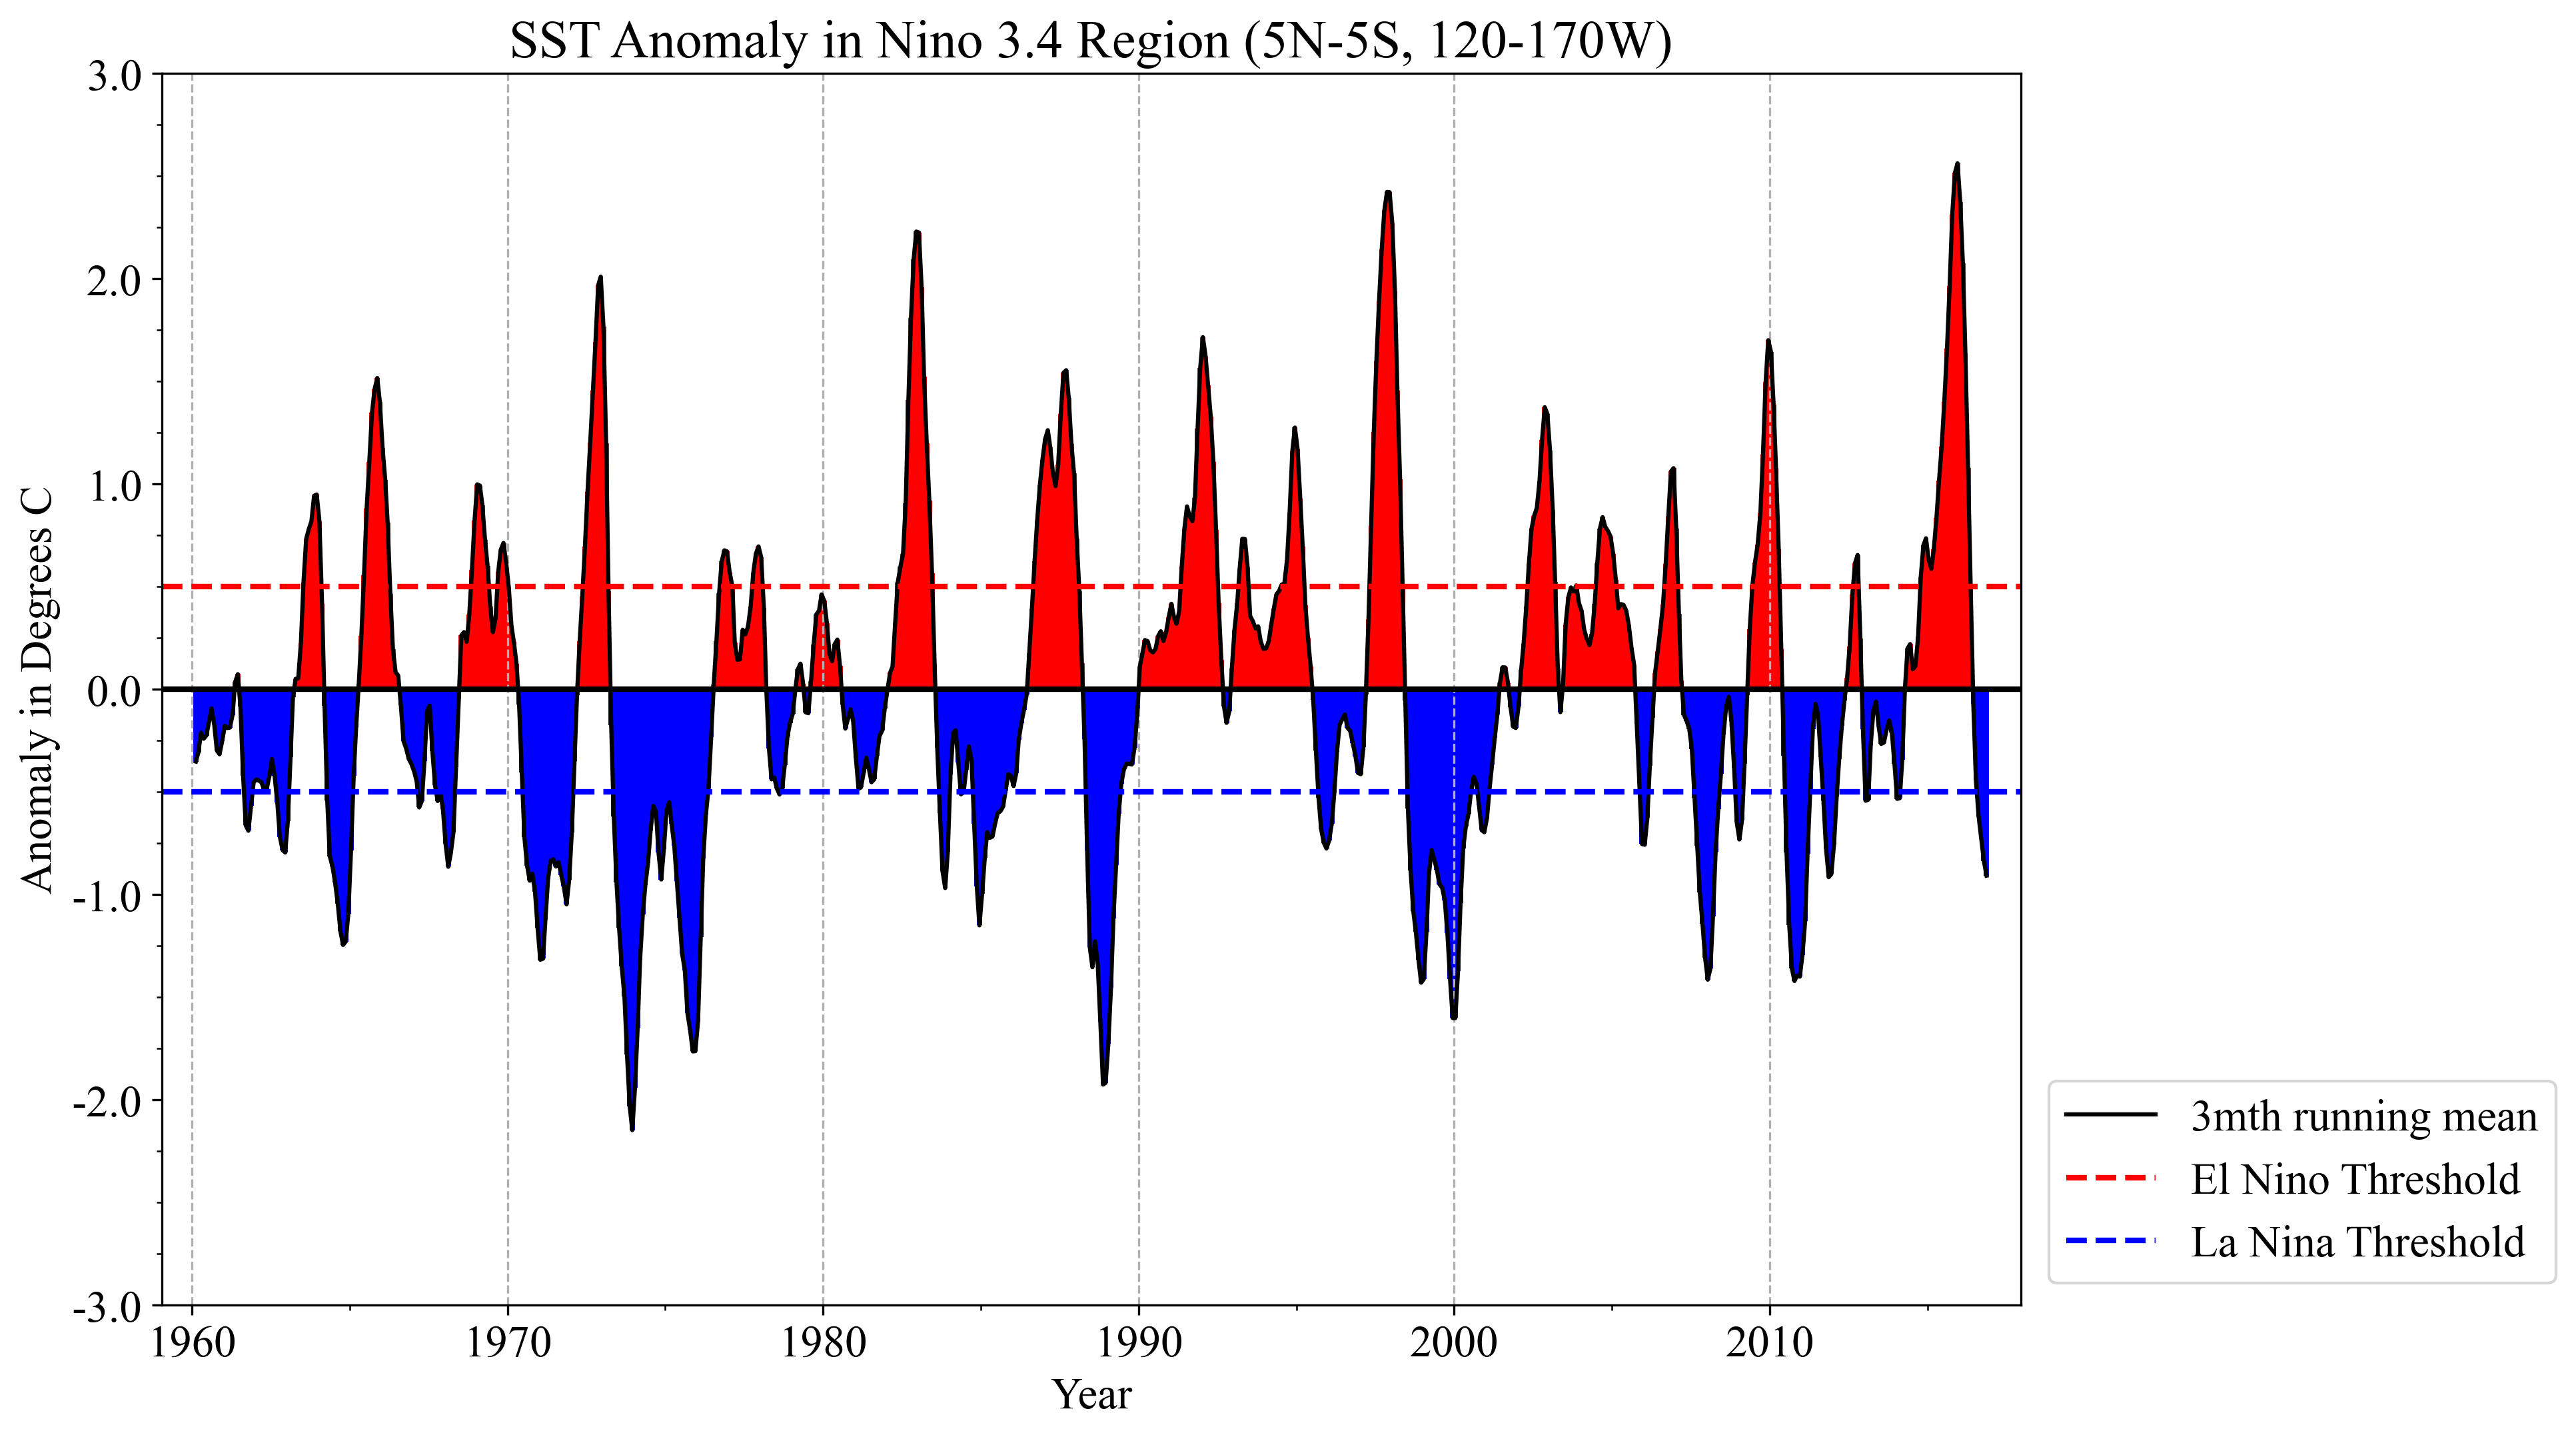

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 16

# === 读取 NOAA SST 数据 ===
Nino = xr.open_dataset("C:/Users/xiezhengyang/Desktop/NOAA_NCDC_ERSST_v3b_SST.nc")

# === 1.1 计算 Niño 3.4 区域 SST 异常 ===
# Niño 3.4 区域：5S-5N, 170W-120W → lon 190-240, lat -5~5
Nino_34 = Nino.sel(lon=slice(190, 240), lat=slice(-5, 5))

# 按月份计算长期 climatology
climatology = Nino_34.groupby('time.month').mean('time')

# 计算 SST 异常 = 原始 SST - 对应月份平均
anomalies = Nino_34.groupby('time.month') - climatology

# 打印前 5 个时间点查看
print("=== Nino 3.4 区域 SST 数据（前5个时间点） ===")
print(Nino_34.isel(time=slice(0, 5)))

print("\n=== Climatology（前5个月） ===")
print(climatology.isel(month=slice(0, 5)))

print("\n=== SST Anomalies（前5个时间点） ===")
print(anomalies.isel(time=slice(0, 5)))

# === 1.2 生成 Niño 3.4 可视化 ===
# 3 个月滑动平均 → 区域平均 → 转 DataArray
Nino_phe_anomalies = anomalies.rolling(time=3, center=True).mean()
Nino_phe_anomalies = Nino_phe_anomalies.mean(['lat', 'lon']).to_array().squeeze()

# 时间序列
time_series = pd.to_datetime(Nino_phe_anomalies['time'].values)

# 绘图
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# 黑色折线：3 个月滑动平均
ax.plot(time_series, Nino_phe_anomalies, color='black', linewidth=1.5, label='3mth running mean')

# 阈值线
El_nino_thre, La_nina_thre = 0.5, -0.5
ax.axhline(y=El_nino_thre, color='red', linestyle='--', linewidth=2, label='El Nino Threshold')
ax.axhline(y=La_nina_thre, color='blue', linestyle='--', linewidth=2, label='La Nina Threshold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=2)

# 条形图：正异常红色，负异常蓝色
bar_colors = ['red' if v >= 0 else 'blue' for v in Nino_phe_anomalies]
ax.bar(time_series, Nino_phe_anomalies, color=bar_colors, zorder=0, width=60)

# 坐标轴标签
ax.set_xlabel('Year')
ax.set_ylabel('Anomaly in Degrees C')

# x 轴范围
delta = pd.Timedelta(days=365)
ax.set_xlim(time_series.min() - delta, time_series.max() + delta)

# x轴刻度：主刻度10年，次刻度5年
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_minor_locator(mdates.YearLocator(5))

# y轴范围和刻度
ax.set_ylim(-3.0, 3.0)
ax.set_yticks(np.linspace(-3.0, 3.0, 7))
ax.set_yticks(np.arange(-3.0, 3.25, 0.25), minor=True)
ax.yaxis.set_major_formatter('{:.1f}'.format)

# 标题、图例、网格
plt.title('SST Anomaly in Nino 3.4 Region (5N-5S, 120-170W)')
plt.legend(loc='lower right', bbox_to_anchor=(1.3, 0))
plt.grid(axis='x', linestyle='--')

plt.show()


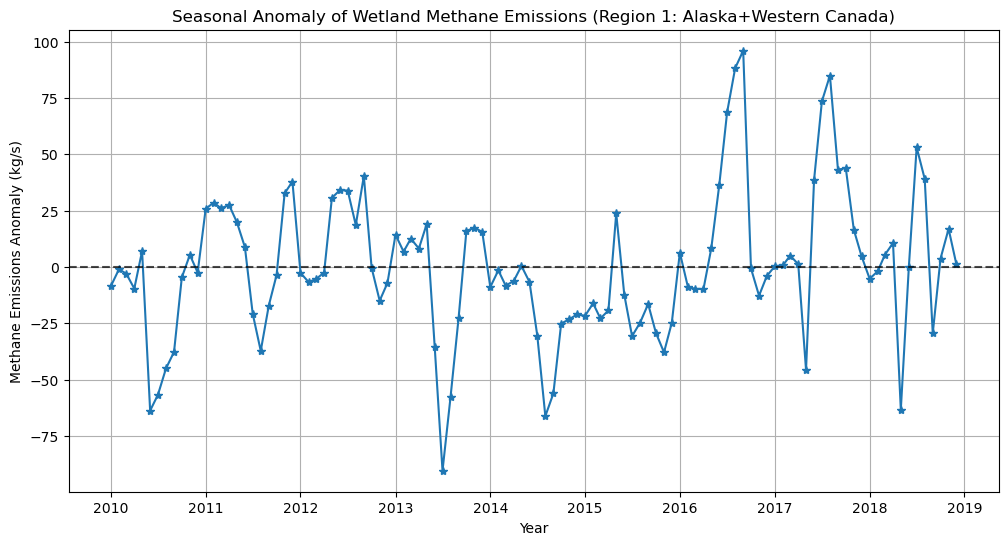

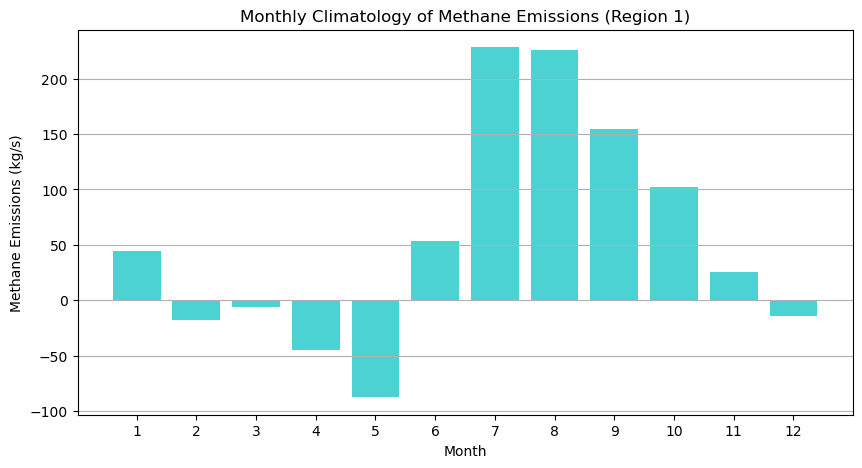

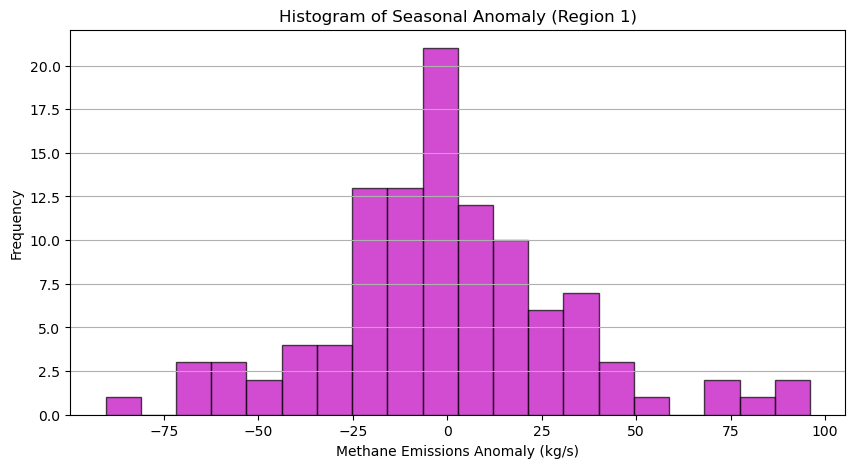

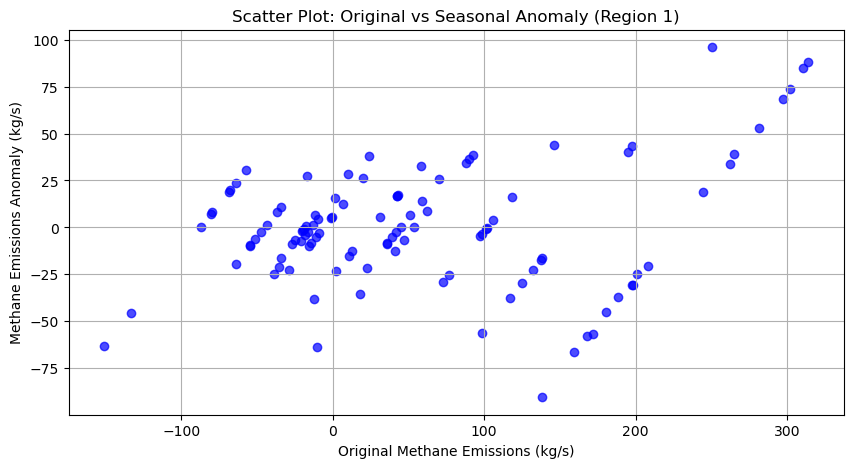

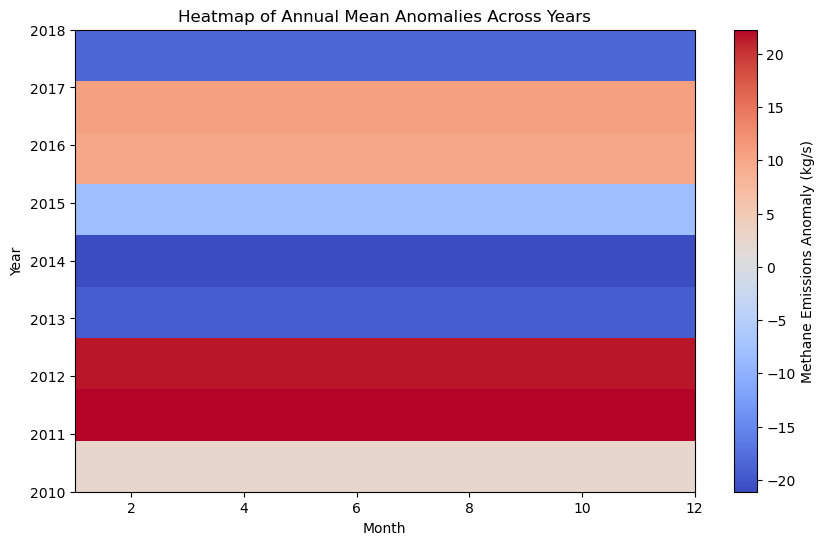

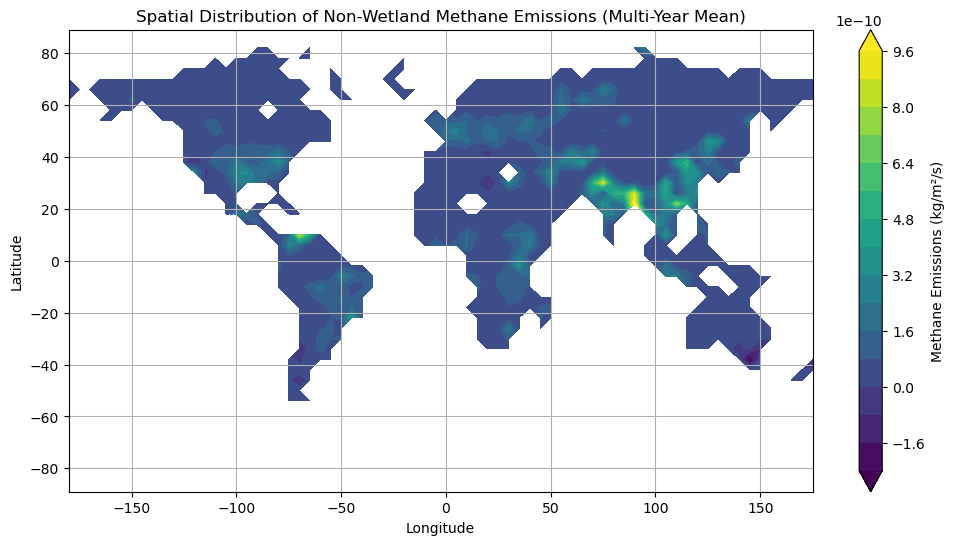

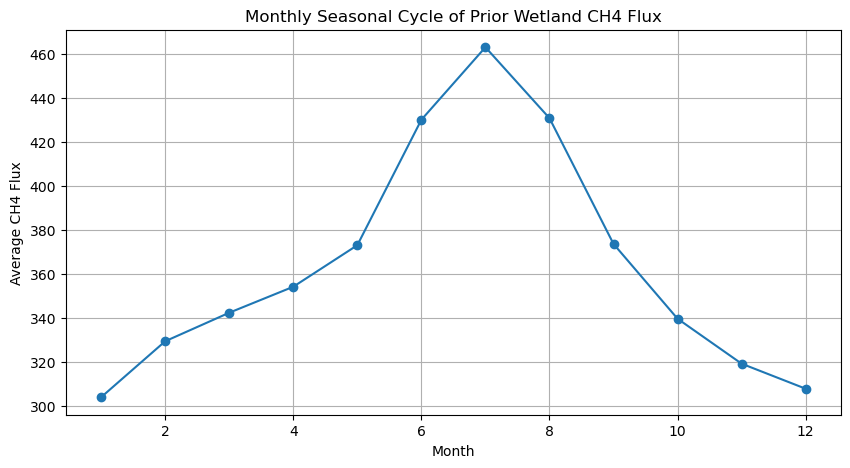

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# 加载 NetCDF 数据
dataset = xr.open_dataset("C:/Users/xiezhengyang/Desktop/GlobalInv_GOSAT_CH4Flux_2010-2018_v1.nc", engine="netcdf4")

# 显示数据变量以了解其结构
dataset

# 检查 wetland_region 值以确定有效索引
wetland_regions = dataset["wetland_region"].values
wetland_regions
# 选择第一个湿地区域的数据（区域 1：阿拉斯加 + 加拿大西部）
region_data = dataset["post_wetland"].sel(wetland_region=1)

# 计算所选区域的气候态和异常值
region_climatology = region_data.groupby("time.month").mean(dim="time")
region_anomaly = region_data.groupby("time.month") - region_climatology

# 绘制所选区域的季节性异常值时间序列
plt.figure(figsize=(12, 6))
region_anomaly.plot(marker="*")
plt.axhline(0, color="k", linestyle="--", alpha=0.7)
plt.title("Seasonal Anomaly of Wetland Methane Emissions (Region 1: Alaska+Western Canada)")
plt.xlabel("Year")
plt.ylabel("Methane Emissions Anomaly (kg/s)")
plt.grid()
plt.show()

# 1. 区域 1 的气候态（平均月循环）
plt.figure(figsize=(10, 5))
plt.bar(range(1, 13), region_climatology, color="c", alpha=0.7)
plt.title("Monthly Climatology of Methane Emissions (Region 1)")
plt.xlabel("Month")
plt.ylabel("Methane Emissions (kg/s)")
plt.xticks(range(1, 13))
plt.grid(axis="y")
plt.show()

# 2. 季节性异常值的直方图
plt.figure(figsize=(10, 5))
plt.hist(region_anomaly, bins=20, color="m", alpha=0.7, edgecolor="k")
plt.title("Histogram of Seasonal Anomaly (Region 1)")
plt.xlabel("Methane Emissions Anomaly (kg/s)")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

# 3. 原始值与异常值的散点图（用于观察变异性）
plt.figure(figsize=(10, 5))
plt.scatter(region_data, region_anomaly, alpha=0.7, color="b")
plt.title("Scatter Plot: Original vs Seasonal Anomaly (Region 1)")
plt.xlabel("Original Methane Emissions (kg/s)")
plt.ylabel("Methane Emissions Anomaly (kg/s)")
plt.grid()
plt.show()

# 4. 跨年份月度气候态的热图
monthly_anomalies = region_anomaly.groupby("time.year").mean(dim="time")
plt.figure(figsize=(10, 6))
plt.imshow(
    monthly_anomalies.values[:, None],
    aspect="auto",
    cmap="coolwarm",
    interpolation="none",
    extent=[1, 12, 2010, 2018],
)
plt.colorbar(label="Methane Emissions Anomaly (kg/s)")
plt.title("Heatmap of Annual Mean Anomalies Across Years")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

# 5. 绘制多年平均非湿地甲烷排放的空间分布
plt.figure(figsize=(12, 6))
plt.contourf(
    dataset["lon"], dataset["lat"], dataset["post_nonwetland"],
    cmap="viridis", levels=20, extend="both"
)
plt.colorbar(label="Methane Emissions (kg/m²/s)")
plt.title("Spatial Distribution of Non-Wetland Methane Emissions (Multi-Year Mean)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()

# 6. 绘制 prior_wetland 的季节性循环，对年份进行平均以显示月度循环
monthly_cycle_prior_wetland = dataset["prior_wetland"].groupby("time.month").mean("time").mean(dim="wetland_region")
plt.figure(figsize=(10, 5))
monthly_cycle_prior_wetland.plot(marker='o')
plt.title('Monthly Seasonal Cycle of Prior Wetland CH4 Flux')
plt.xlabel('Month')
plt.ylabel('Average CH4 Flux')
plt.grid(True)
plt.show()